In [1]:
%pip install -q numpy seaborn matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sns.set_style("whitegrid")
pd.set_option("display.max_columns",50)

In [3]:
df = pd.read_csv("titanic_dataset.csv")

In [4]:
df.shape

(782, 15)

In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [6]:
# Identify numerical and categorical features
num_cols = ["age","fare","sibsp","parch"]
cat_cols = ["survived","pclass","sex","class","who","adult_male","embark_town","alone"]
print("\nNumerical Columns:",num_cols)
print("Categorical Columns:",cat_cols)



Numerical Columns: ['age', 'fare', 'sibsp', 'parch']
Categorical Columns: ['survived', 'pclass', 'sex', 'class', 'who', 'adult_male', 'embark_town', 'alone']


In [7]:
df_num = df[num_cols].dropna()

In [8]:
df["survived_label"] = df["survived"].map({0:"No",1: "Yes"})

### 3.Numerical Vs Numerical

3.1.Scatter Plot

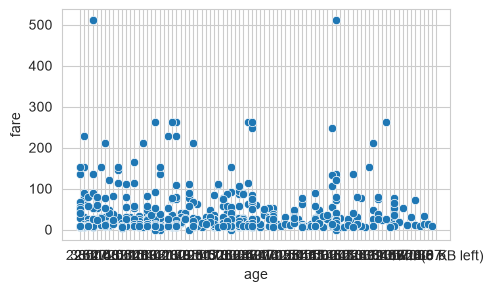

In [9]:
plt.figure(figsize=(5,3))
sns.scatterplot(x=df["age"],y=df["fare"])
plt.xlabel("age")
plt.ylabel("fare")
plt.show()

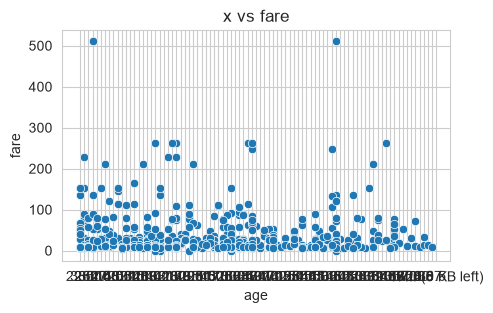

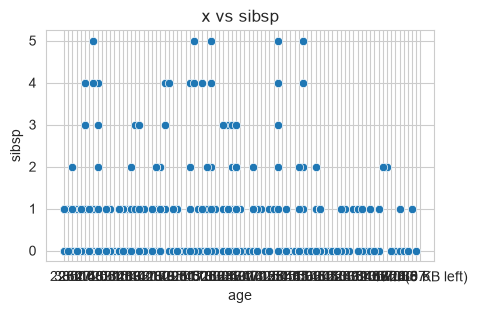

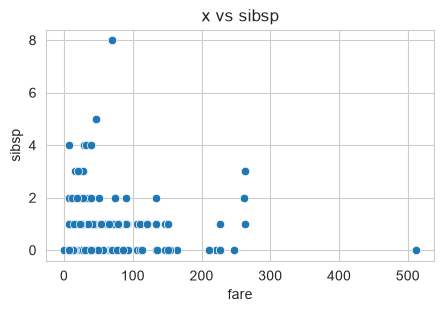

In [10]:
num_pairs = [
    ["age","fare"],
    ["age","sibsp"],
    ["fare","sibsp"]
]

for x,y in num_pairs:
   plt.figure(figsize=(5,3))
   sns.scatterplot(x=df[x],y=df[y])
   plt.title(f"x vs {y}")
   plt.xlabel(x)
   plt.ylabel(y)
   plt.show() 

### 3.2.Correlation Matrix

In [11]:
print("Correlation Matrix")
df_num.corr()

# -1 -> High Negative Correlation ;  + 1 -> high positive correlation


Correlation Matrix


,age,fare,sibsp,parch
age,1.000000,0.086271,-0.302358,-0.178324
fare,0.086271,1.000000,0.131649,0.201883
sibsp,-0.302358,0.131649,1.000000,0.382818
parch,-0.178324,0.201883,0.382818,1.000000


In [12]:
num_cols

['age', 'fare', 'sibsp', 'parch']

In [13]:
print(df_num[num_cols].dtypes)



age          str
fare     float64
sibsp    float64
parch    float64
dtype: object


In [14]:
df_num["age"] = pd.to_numeric(df_num["age"], errors="coerce")

In [15]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

In [16]:
print("Pearson Correlation with  fare:")
for col in num_cols:
    if col != "fare":
        r,p = pearsonr(df_num[col],df_num["fare"])
        print(f"{col} vs fare: r={r:.3f}; p={p:.3f}")

Pearson Correlation with  fare:
age vs fare: r=0.086; p=0.031
sibsp vs fare: r=0.132; p=0.001
parch vs fare: r=0.202; p=0.000


### 4.Numerical vs Categorical Features

4.1.BoxPlots

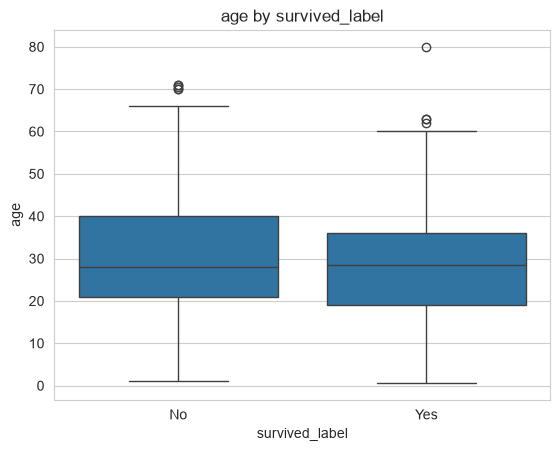

In [17]:
plt.Figure(figsize=(5,3))
sns.boxplot(x=df["survived_label"],y=df["age"])
plt.xlabel("survived_label")
plt.ylabel("age")
plt.title("age by survived_label")
plt.show()

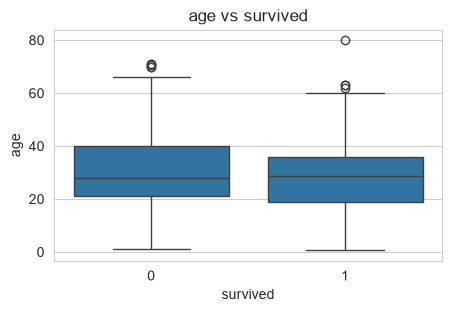

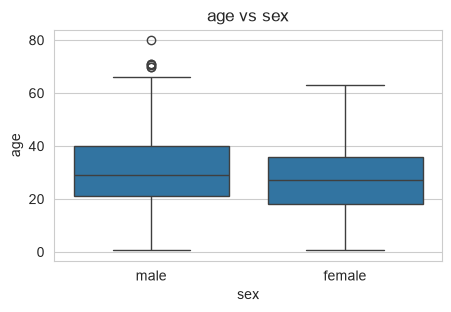

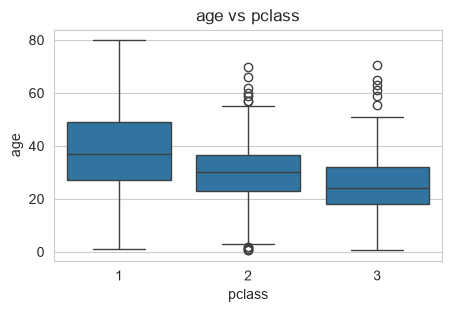

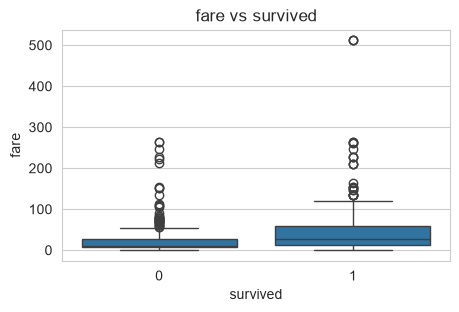

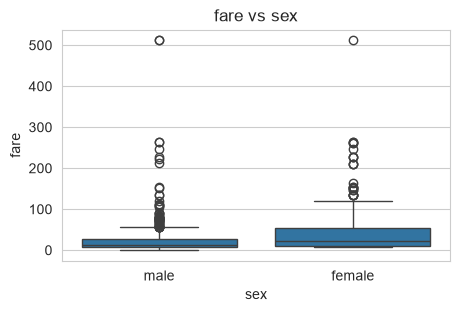

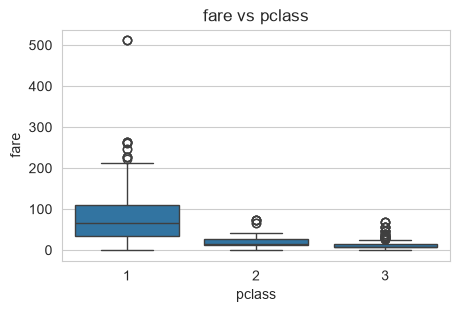

In [18]:
num_for_box = ["age","fare"]
cat_for_box = ["survived","sex","pclass"]

for num in num_for_box:
    for cat in cat_for_box:
        plt.figure(figsize=(5,3))
        sns.boxplot(x=df[cat],y=df[num])
        plt.title(f"{num} vs {cat}")
        plt.xlabel(cat)
        plt.ylabel(num)

### 4.2. Grouped Statistics

In [19]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1.0,0.0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1.0,0.0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0.0,0.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1.0,0.0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0.0,0.0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


In [20]:
df_num.columns

Index(['age', 'fare', 'sibsp', 'parch'], dtype='str')

In [21]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'survived_label'],
      dtype='str')

In [22]:
df['survived_label']

0       No
1      Yes
2      Yes
3      Yes
4       No
      ... 
777    Yes
778     No
779    Yes
780    Yes
781    Yes
Name: survived_label, Length: 782, dtype: str

In [23]:
print(num_cols)
print(df[num_cols].dtypes)

['age', 'fare', 'sibsp', 'parch']
age      float64
fare     float64
sibsp    float64
parch    float64
dtype: object


In [24]:
df[num_cols + ["survived_label"]].groupby("survived_label").mean() 

,age,fare,sibsp,parch
survived_label,,,,
No,31.017663,22.741491,0.527197,0.322176
Yes,28.442598,49.763587,0.485149,0.452145


In [25]:
df[["age","fare"]]

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
777,5.0,12.4750
778,NaN,7.7375
779,43.0,211.3375
780,13.0,7.2292


In [26]:
print(df["age"].describe())
print(df["age"].mean())
print(df["age"].mode())
print(df["age"].median())

count    622.000000
mean      29.966109
std       14.576037
min        0.670000
25%       21.000000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64
29.96610932475884
0    24.0
Name: age, dtype: float64
28.0


In [27]:
# df= df["age"].fillna().mean()

In [28]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1.0,0.0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1.0,0.0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0.0,0.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1.0,0.0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0.0,0.0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No
5,0,3,male,NaN,0.0,0.0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True,No
6,0,1,male,54.0,0.0,0.0,51.8625,S,First,man,True,E,Southampton,no,True,No
7,0,3,male,2.0,3.0,1.0,21.0750,S,Third,child,False,NaN,Southampton,no,False,No
8,1,3,female,27.0,0.0,2.0,11.1333,S,Third,woman,False,NaN,Southampton,yes,False,Yes
9,1,2,female,14.0,1.0,0.0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False,Yes


In [29]:
for cat in ["survived_label","sex","pclass"]:
    print(f"Grouped Statistics for fare by {cat}:")
    # print(df.groupby(cat)["fare"].describe())
    print(df.groupby(cat)["fare"].mean())
    print("-"*50)

Grouped Statistics for fare by survived_label:
survived_label
No     22.741491
Yes    49.763587
Name: fare, dtype: float64
--------------------------------------------------
Grouped Statistics for fare by sex:
sex
female    45.347835
male      26.562399
Name: fare, dtype: float64
--------------------------------------------------
Grouped Statistics for fare by pclass:
pclass
1    88.774057
2    20.810823
3    13.275770
Name: fare, dtype: float64
--------------------------------------------------


#### 5. Categorical Vs Categorical features

5.1.Crosstab examples

In [30]:
print("Crosstab: sex vs  survived")
print(pd.crosstab(df["sex"],df["survived_label"]))

print("Crosstab: pclass vs survived")
print(pd.crosstab(df["pclass"],df["survived_label"]))

Crosstab: sex vs  survived
survived_label   No  Yes
sex                     
female           70  208
male            408   96
Crosstab: pclass vs survived
survived_label   No  Yes
pclass                  
1                72  119
2                84   80
3               322  105


5.2.Countplot

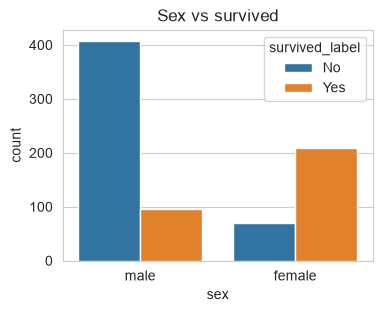

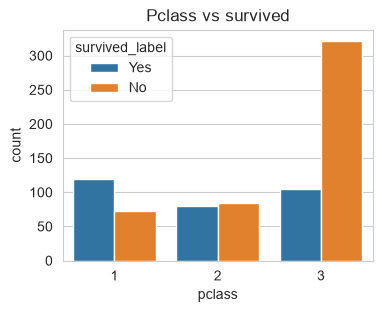

In [31]:
plt.figure(figsize=(4,3))
sns.countplot(x=df["sex"],hue=df["survived_label"])
plt.title("Sex vs survived")
plt.show()

plt.figure(figsize=(4,3))
sns.countplot(x=df["pclass"],hue=df["survived_label"])
plt.title("Pclass vs survived")
plt.show()

Summary

In [32]:
print("\nBivariate and MultiVariatae Analysis Completed")
print("~Numerical vs numerical:scatter + correlations")
print("~Numerical vs numerical:scatter + boxplots + group stats")
print("~Categorical vs categorical: crosstab + countplot")


Bivariate and MultiVariatae Analysis Completed
~Numerical vs numerical:scatter + correlations
~Numerical vs numerical:scatter + boxplots + group stats
~Categorical vs categorical: crosstab + countplot


**Pairplot**

In [33]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1.0,0.0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1.0,0.0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0.0,0.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1.0,0.0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0.0,0.0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


In [34]:
print(df.columns)
print(df["survived_label"].dtype)


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'survived_label'],
      dtype='str')
str


In [35]:
pairplot_cols = num_cols + ["survived_label"]

In [36]:
print(pairplot_cols)

['age', 'fare', 'sibsp', 'parch', 'survived_label']


      age      fare  sibsp  parch survived_label
0    22.0    7.2500    1.0    0.0             No
1    38.0   71.2833    1.0    0.0            Yes
2    26.0    7.9250    0.0    0.0            Yes
3    35.0   53.1000    1.0    0.0            Yes
4    35.0    8.0500    0.0    0.0             No
..    ...       ...    ...    ...            ...
774  54.0   23.0000    1.0    3.0            Yes
775  18.0    7.7500    0.0    0.0             No
777   5.0   12.4750    0.0    0.0            Yes
779  43.0  211.3375    0.0    1.0            Yes
780  13.0    7.2292    0.0    0.0            Yes

[622 rows x 5 columns]


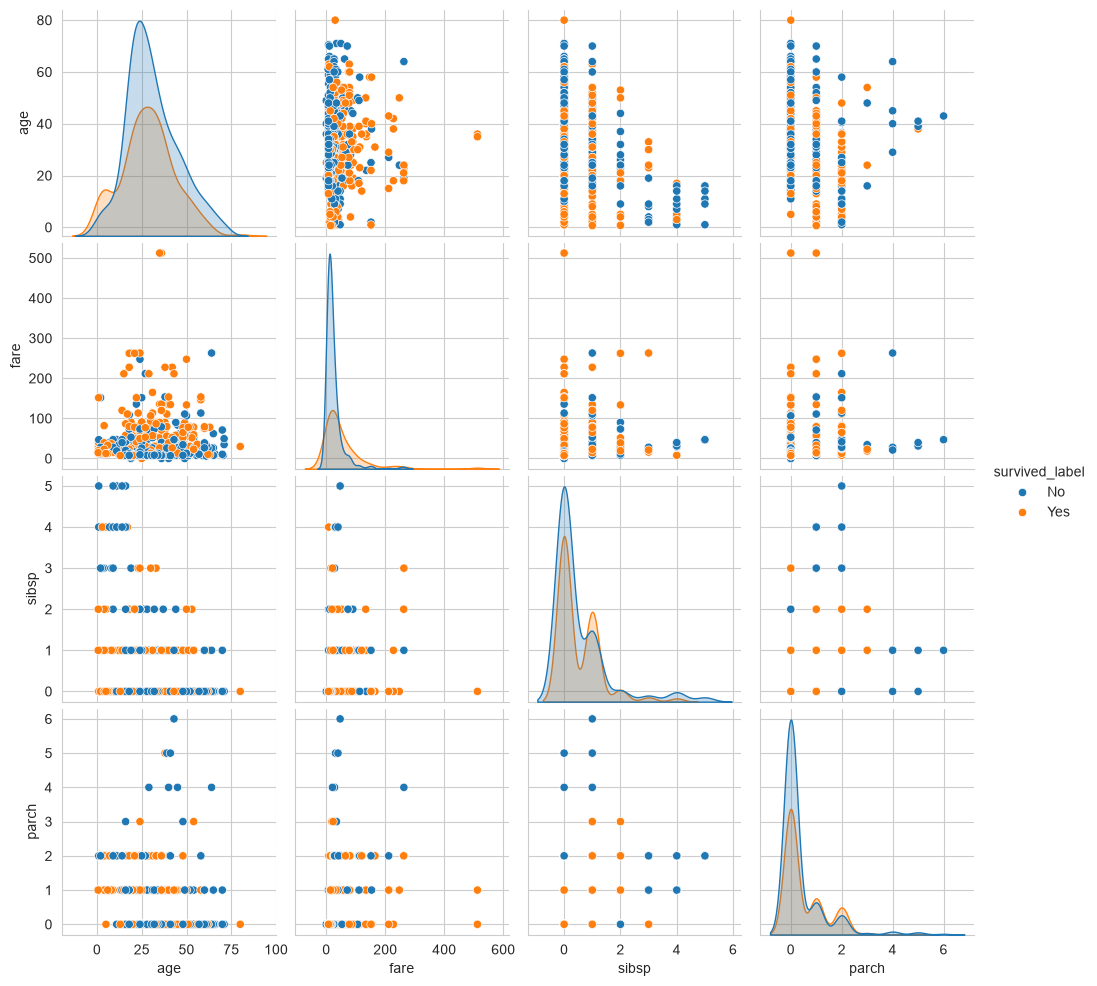

In [37]:
df_pair = df[pairplot_cols].dropna()
print(df_pair)
sns.pairplot(df_pair,hue="survived_label")
plt.show()

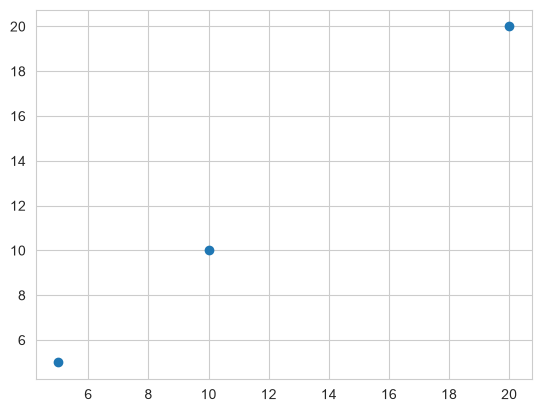

In [38]:
plt.scatter([5,10,20],[5,10,20])
plt.show()

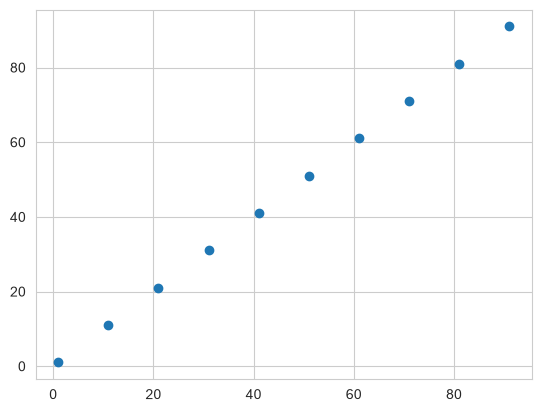

In [39]:
x = np.arange(1,100,10)
plt.scatter(x,x)
plt.show()

<Axes: xlabel='age', ylabel='fare'>

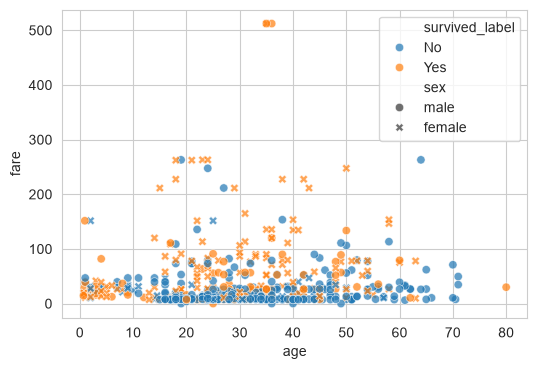

In [40]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data = df,
    x = "age",
    y = "fare",
    hue= "survived_label",
    style="sex",
    alpha  = 0.7
)

**Corelation heat map**

In [41]:
df_num.head()

,age,fare,sibsp,parch
0,22.0,7.2500,1.0,0.0
1,38.0,71.2833,1.0,0.0
2,26.0,7.9250,0.0,0.0
3,35.0,53.1000,1.0,0.0
4,35.0,8.0500,0.0,0.0


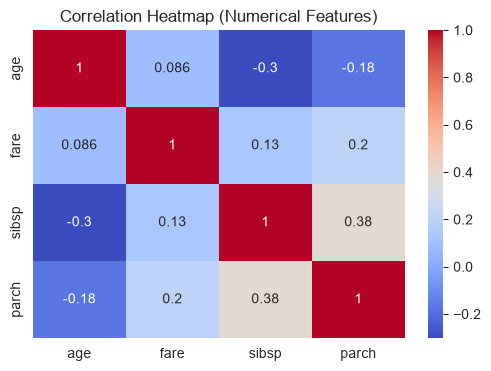

In [42]:
plt.figure(figsize=(6,4))
sns.heatmap(df_num.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

**Cluster Maps**

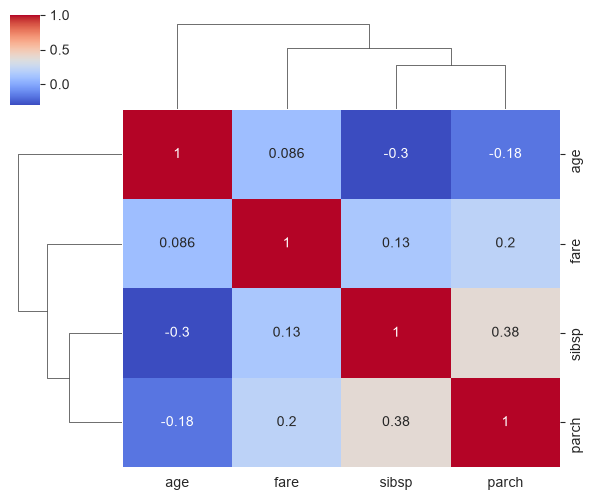

In [43]:
sns.clustermap(df_num.corr(),annot=True,cmap="coolwarm",figsize=(6,5))
plt.show()

**Interaction & Sub-group Pattern**

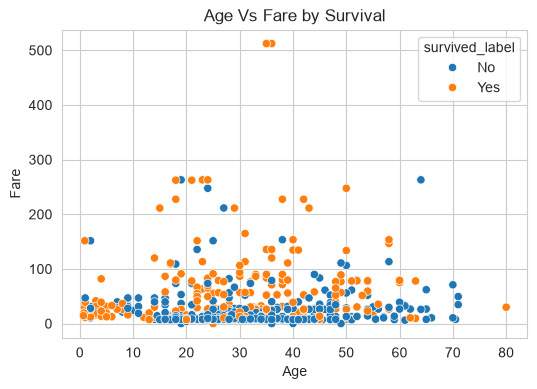

In [44]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"],y=df["fare"],hue=df["survived_label"])
plt.title("Age Vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

**Sub-groups:sibilings/spouses**

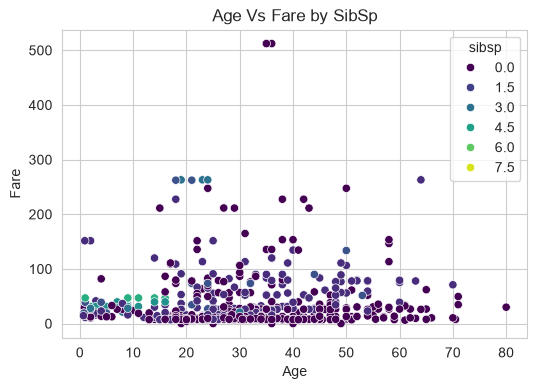

In [48]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"],y=df["fare"],hue=df["sibsp"],palette="viridis")
plt.title("Age Vs Fare by SibSp")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

**Summary**

In [49]:
print("~ Multivariate:pairplot,heatmap: cluster map")
print("~ Intraction and subgroup patterns plotted")

~ Multivariate:pairplot,heatmap: cluster map
~ Intraction and subgroup patterns plotted
